In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

In [2]:
dfX = pd.read_csv('x_train.csv')
dfY = pd.read_csv('y_train.csv')

In [3]:
dfX.head()

,ID,Humidity,M12,M13,M14,M15,M4,M5,M6,M7,R,S1,S2,S3
0,0,0.098160,-0.175981,-0.086469,-0.041465,-0.021153,0.197597,0.054646,-0.009277,0.001855,1.007242,1.013007,1.000563,0.999397
1,1,0.000307,-0.066416,0.036071,0.032636,-0.000573,2.568494,1.883142,0.779251,0.262231,0.971428,0.996735,1.002226,1.013063
2,2,0.000388,0.190943,0.187540,0.143680,0.092635,-0.147460,-0.021174,0.040079,0.065790,1.302238,0.905275,0.953600,0.986347
3,3,0.761003,-0.151393,-0.083723,-0.048982,-0.018259,0.045380,0.102427,0.012915,0.004453,1.013741,1.004315,1.012301,1.009465
4,4,0.107808,0.074818,0.042692,0.026169,0.019134,-0.056284,-0.011193,0.010233,0.012205,0.998659,1.005154,1.000096,0.999553


In [4]:
dfY.head()

,ID,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c14,c15,c16,c17,c18,c19,c20,c21,c22,c23
0,0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1,0.000000,0.0,0.176471,0.176471,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.176471,0.0,0.0,0.176471,0.000000
2,2,0.128465,0.0,0.128465,0.128465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.128465,0.000000,0.0,0.0,0.128465,0.000000
3,3,0.000000,0.0,0.263736,0.263736,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.263736,0.263736
4,4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000


# Explication du Challenge

## Objectif Global

Construire un modèle de **détection de gaz toxiques** à partir de mesures de capteurs, capable de prédire un **niveau d'alarme** pour 23 catégories de gaz différentes.

---

## Les Données

### Entrées (features) :
| Capteurs | Description |
|----------|-------------|
| **M4-M7, M12-M15** | 8 capteurs principaux (physiquement proches) |
| **S1-S3, R** | 4 capteurs complémentaires |
| **Humidity** | Humidité absolue (facteur perturbateur) |

### Sorties (targets) :
- **23 classes (c1-c23)** : chacune représente une catégorie de gaz (ex: sarin, agent vésicant...)
- Valeur entre **0 et 1** → niveau d'alarme

---

## La Métrique (à minimiser)

C'est un **RMSE pondéré** :

```
Pour chaque classe i :
  - Si ĉᵢ >= 0.5 (alarme réelle) → fᵢ = 1.2  ← PENALITÉ PLUS FORTE
  - Si ĉᵢ < 0.5  (pas d'alarme)  → fᵢ = 1.0

Erreur = sqrt( mean( fᵢ × (cᵢ - ĉᵢ)² ) )
```

### Ce que ça implique :
> **Rater une vraie alarme est plus grave que déclencher une fausse alarme**

→ Le modèle doit être **sensible** (recall élevé), quitte à avoir quelques faux positifs

---

## Difficultés Clés

```
1. Généralisation : les conditions de test ≠ conditions d'entraînement
   (humidité, concentrations différentes)

2. Multi-output : 23 sorties simultanées

3. Métrique asymétrique : manquer un gaz dangereux = très pénalisant

4. Contrainte pratique : modèle léger (embarqué sur appareil portable)
```

---

## Résumé en une phrase

> Prédire si un gaz toxique est présent (et lequel) à partir de 13 mesures de capteurs, en **privilégiant la détection** des vrais dangers sur l'évitement des fausses alarmes, avec un modèle qui doit **bien généraliser** à de nouvelles conditions physiques.

In [5]:
dfX = dfX.drop('ID', axis=1)
dfY = dfY.drop('ID', axis=1)

In [6]:
min_dfX = dfX.min()
min_dfX

Humidity     0.000305
M12        -13.021540
M13        -11.844691
M14         -9.117980
M15         -4.165993
M4          -2.831466
M5          -0.790972
M6          -0.224497
M7          -0.147250
R            0.023324
S1           0.025957
S2           0.151214
S3           0.709661
dtype: float64

In [7]:
max_dfX = dfX.max()
max_dfX

Humidity     0.958255
M12          2.545019
M13          2.864641
M14          2.004906
M15          0.842932
M4          28.245698
M5          28.710670
M6          20.508550
M7          10.714200
R           48.026927
S1           6.626481
S2          55.702963
S3           1.057846
dtype: float64

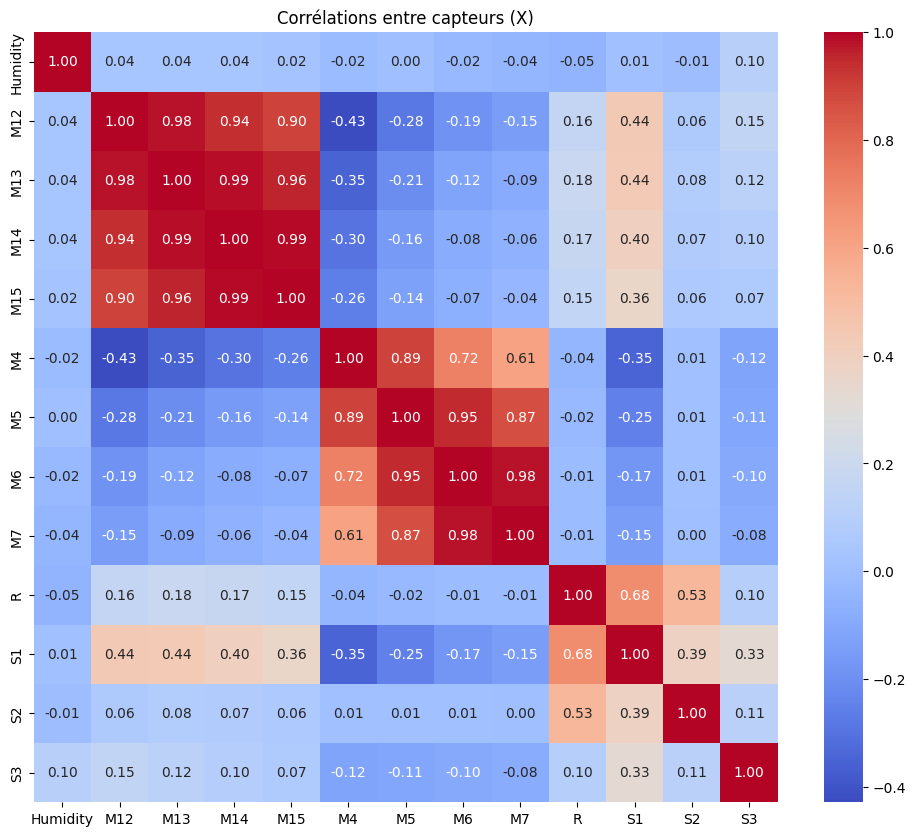

In [8]:
plt.figure(figsize=(12, 10))
corrX = dfX.corr()
sns.heatmap(corrX, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélations entre capteurs (X)")
plt.show()

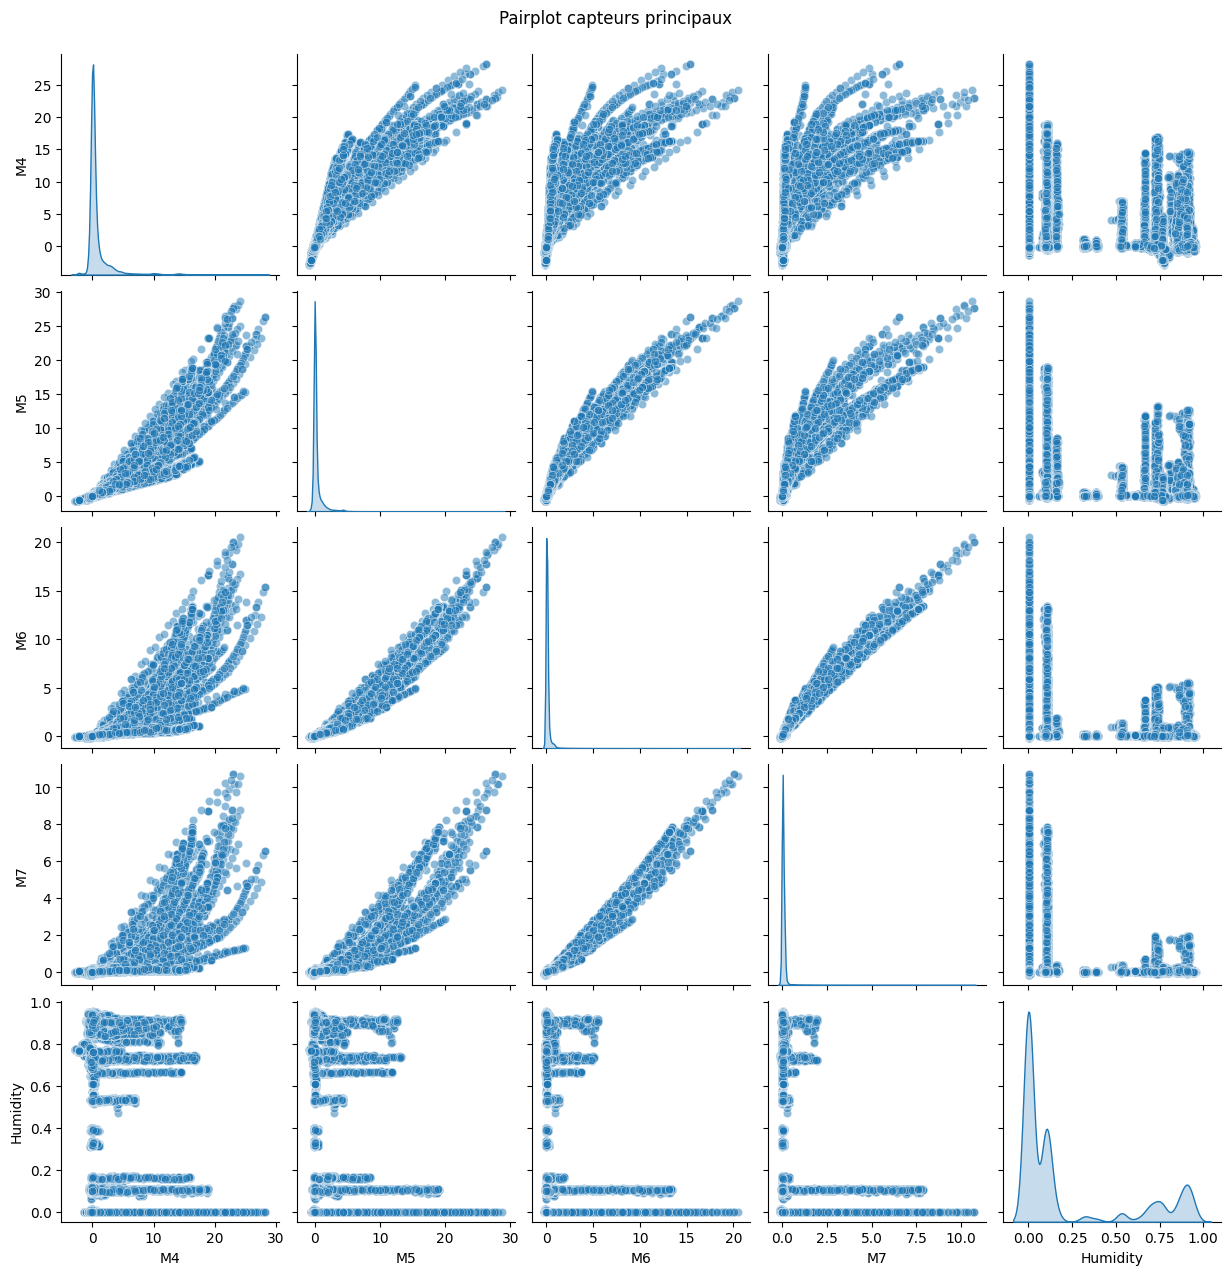

In [9]:
subset = dfX[['M4','M5','M6','M7','Humidity']]
sns.pairplot(subset, diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot capteurs principaux", y=1.02)
plt.show()

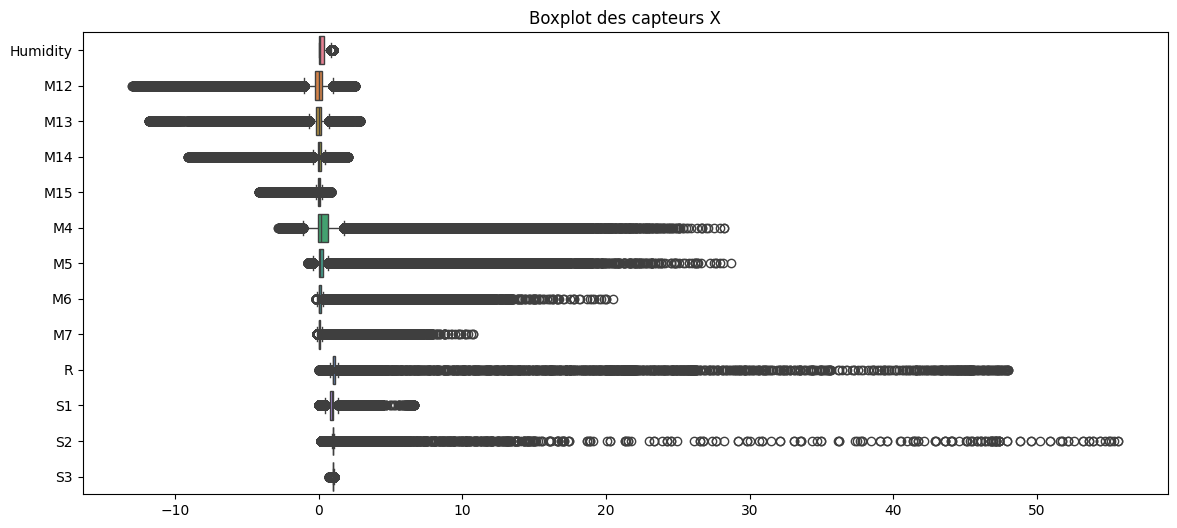

In [10]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=dfX, orient='h')
plt.title("Boxplot des capteurs X")
plt.show()

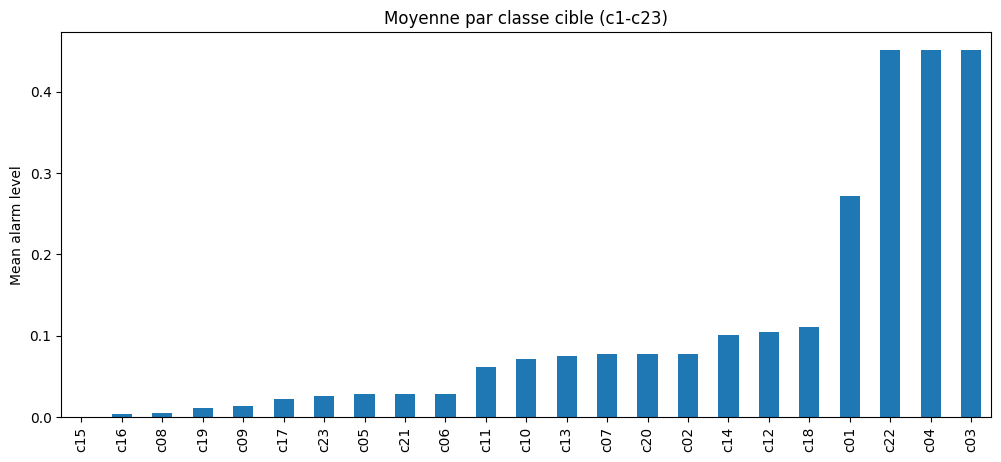

In [11]:
moyennes = dfY.mean().sort_values()
plt.figure(figsize=(12,5))
moyennes.plot(kind='bar')
plt.title("Moyenne par classe cible (c1-c23)")
plt.ylabel("Mean alarm level")
plt.show()

In [12]:
print(dfX.columns)

Index(['Humidity', 'M12', 'M13', 'M14', 'M15', 'M4', 'M5', 'M6', 'M7', 'R',
       'S1', 'S2', 'S3'],
      dtype='str')


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Figure size 1200x1000 with 0 Axes>

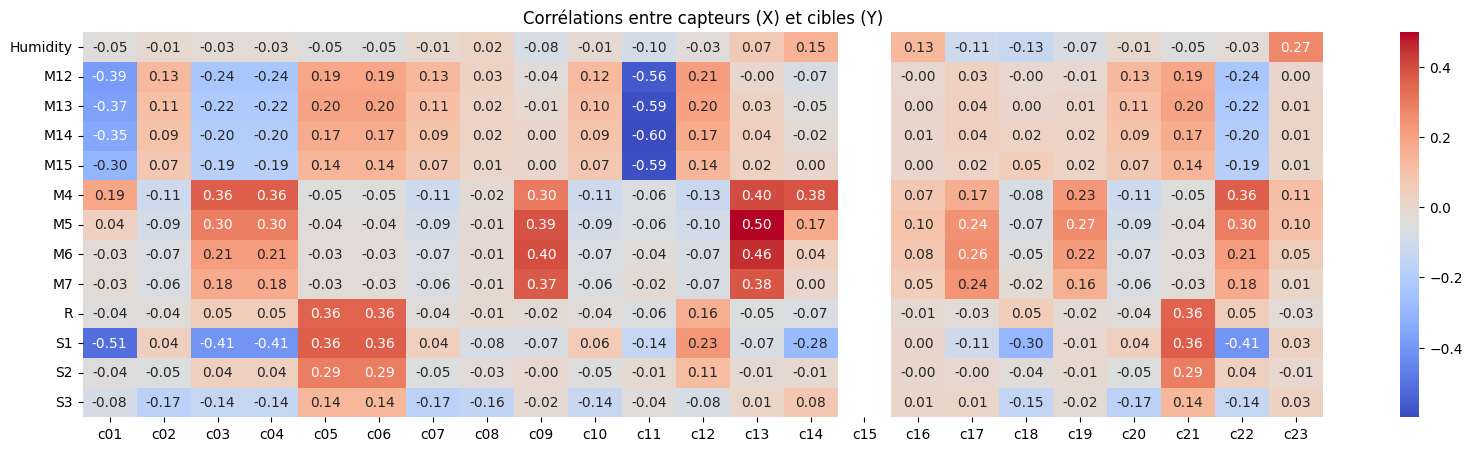

In [13]:
subsetX = dfX[['Humidity', 'M12', 'M13', 'M14', 'M15', 'M4', 'M5', 'M6', 'M7', 'R','S1', 'S2', 'S3']]
subsetY = dfY[['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09', 'c10','c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20','c21', 'c22', 'c23']]

# heatmap
plt.figure(figsize=(12, 10))
corrXY = pd.DataFrame(index=subsetX.columns, columns=subsetY.columns)
for x_col in subsetX.columns:
    for y_col in subsetY.columns:
        corrXY.loc[x_col, y_col] = subsetX[x_col].corr(subsetY[y_col])

plt.figure(figsize=(20, 5))
sns.heatmap(corrXY.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélations entre capteurs (X) et cibles (Y)")
plt.show()

In [14]:
# Assure-toi que dfY est un array 2D (n_samples, 23)
y = dfY.values
X = dfX.values

# Split train/val (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
y_val.shape

(40587, 23)

In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
hgbc = MultiOutputRegressor(
    HistGradientBoostingRegressor(max_iter=100),
    n_jobs=-1
)
hgbc.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,HistGradientB...ingRegressor()
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",-1
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0


In [18]:
y_pred_rf = rf.predict(X_val)
y_pred_hgbc = hgbc.predict(X_val)

In [19]:
y_perd_train_rf = rf.predict(X_train)
y_perd_train_hgbc = hgbc.predict(X_train)

In [20]:
def weighted_rmse_correct(y_true, y_pred):
    """
    y_true : ĉᵢ (valeurs réelles)
    y_pred : Cᵢ (prédictions)
    
    fᵢ = 1.0 si ĉᵢ < 0.5
    fᵢ = 1.2 si ĉᵢ >= 0.5
    
    erreur_échantillon = mean_i( fᵢ * (Cᵢ - ĉᵢ)² )
    métrique finale    = sqrt( mean_échantillons( erreur_échantillon ) )
    """
    # f_i basé sur y_true (ĉᵢ)
    f = np.where(y_true >= 0.5, 1.2, 1.0)
    # Erreur par échantillon = moyenne sur les 23 classes
    per_sample_error = np.mean(f * (y_pred - y_true)**2, axis=1)
    # Moyenne sur tous les échantillons puis racine
    return np.sqrt(np.mean(per_sample_error))

score_val_rf = weighted_rmse_correct(y_val, y_pred_rf)
score_train_rf = weighted_rmse_correct(y_train, y_perd_train_rf)
print(f"Weighted RMSE rf (train) : {score_train_rf:.4f}")
print(f"Weighted RMSE rf (val) : {score_val_rf:.4f}")
print('---------------------------------------')
score_val_hgbc = weighted_rmse_correct(y_val, y_pred_hgbc)
score_train_hgbc = weighted_rmse_correct(y_train, y_perd_train_hgbc)
print(f"Weighted RMSE hgbc (train) : {score_train_hgbc:.4f}")
print(f"Weighted RMSE hgbc (val) : {score_val_hgbc:.4f}")



Weighted RMSE rf (train) : 0.0038
Weighted RMSE rf (val) : 0.0093
---------------------------------------
Weighted RMSE hgbc (train) : 0.0332
Weighted RMSE hgbc (val) : 0.0346


In [21]:
dftest = pd.read_csv('x_test.csv')
X_val_submit = dftest.drop('ID', axis=1).values
# y_pred_test = hgbc.predict(X_val_submit)  # shape (n_rows, 23)

In [22]:
cols = ['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07', 'c08', 'c09',
        'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18',
        'c19', 'c20', 'c21', 'c22', 'c23']

submit_df = pd.DataFrame(y_pred_test, columns=cols)
submit_df.insert(0, 'ID', dftest['ID'].values)

NameError: name 'y_pred_test' is not defined

In [23]:
submit_df.to_csv('submission.csv', index=False)

NameError: name 'submit_df' is not defined

In [24]:
dftest = pd.read_csv('x_test.csv')
dfX = pd.read_csv('x_train.csv')
dfY = pd.read_csv('y_train.csv')

In [25]:
n_test_h0 = (dftest['Humidity'] <= 0.1).sum()
n_x_h0 = (dfX['Humidity'] <= 0.1).sum()
print("dftest H=0 :", n_test_h0)
print("dfX H=0 :", n_x_h0)

dftest H=0 : 14482
dfX H=0 : 121124


In [26]:
if n_x_h0 > n_test_h0:
    # diviser en 2 sous-ensembles
    h0 = dfX[dfX['Humidity'] <= 0.1]
    not_h0 = dfX[dfX['Humidity'] > 0.1]

    # garder aléatoirement n_test_h0 lignes
    h0_down = h0.sample(n=n_test_h0, random_state=42)

    # recomposer
    dfX_balanced = pd.concat([h0_down, not_h0], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    dfX_balanced = dfX.copy()
    print("Pas besoin de sous-échantillonner: dfX a moins ou égal de Humidity==0.")

In [27]:
print("Après:", (dfX_balanced['Humidity'] <= 0).sum(), n_test_h0)

Après: 0 14482


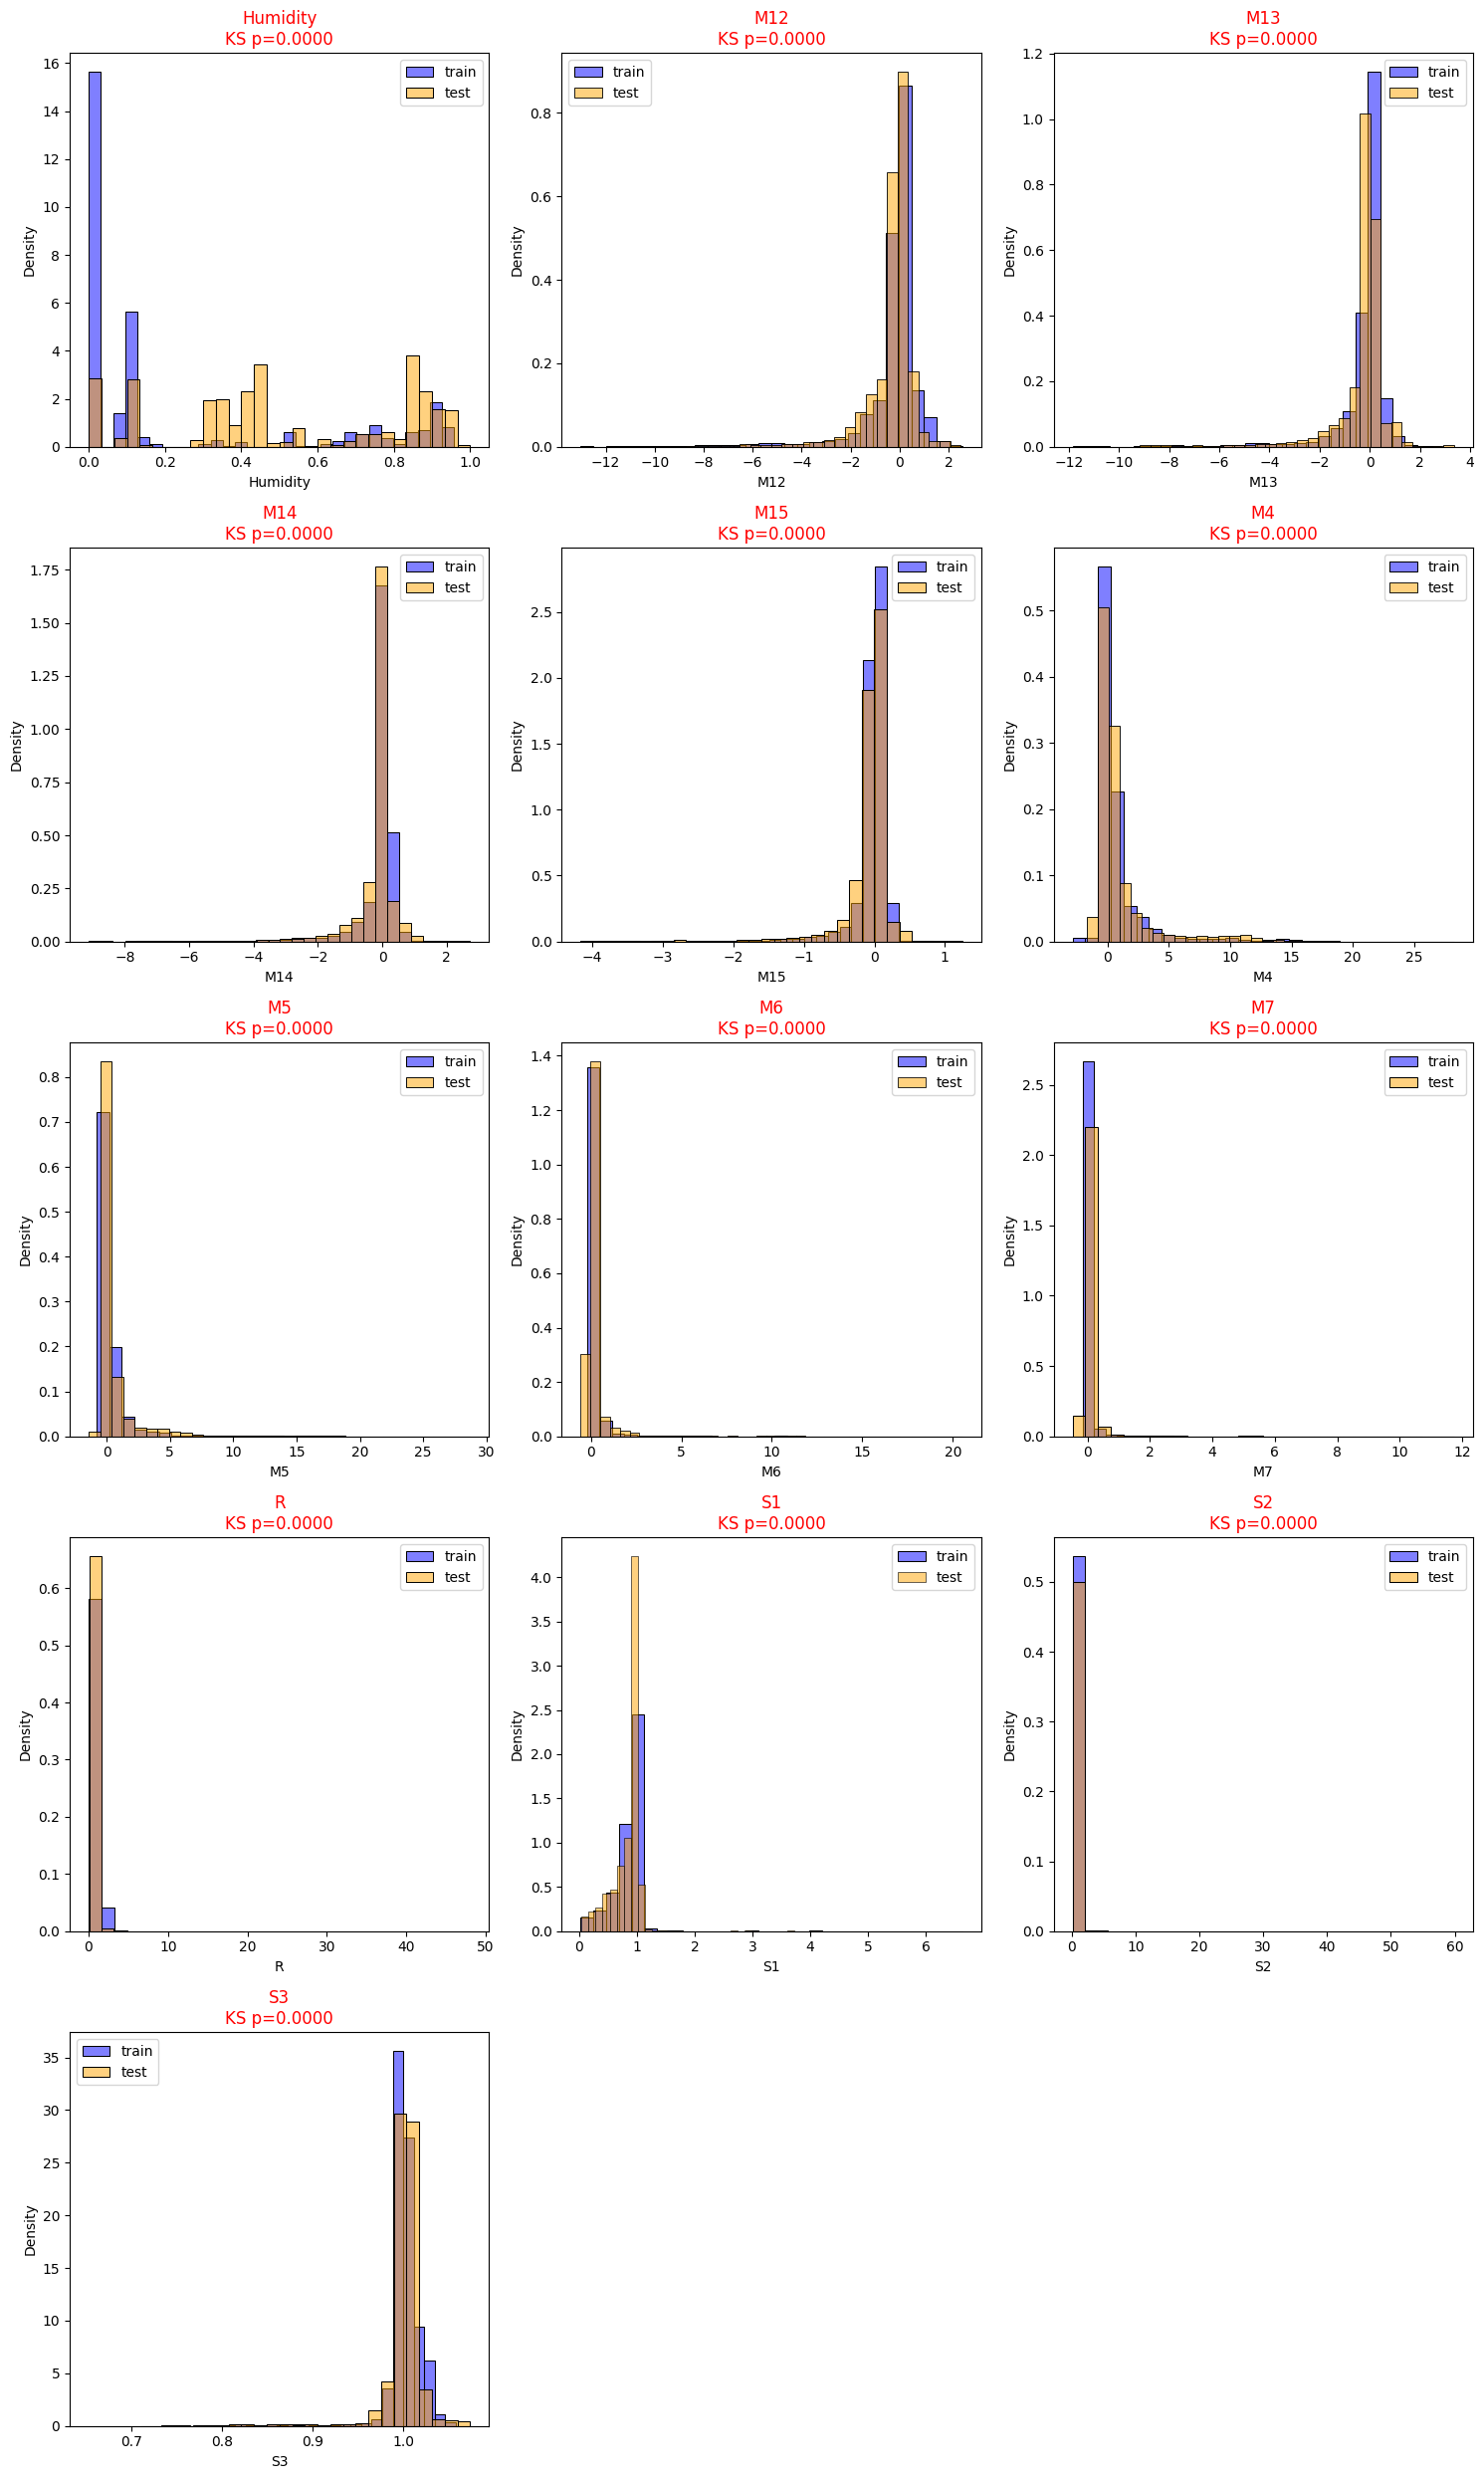


🚨 Features avec distribution différente (p < 0.05) :
  Humidity   → KS stat=0.5885, p=0.0000
  M12        → KS stat=0.1446, p=0.0000
  M13        → KS stat=0.1494, p=0.0000
  M14        → KS stat=0.1353, p=0.0000
  M15        → KS stat=0.1241, p=0.0000
  M4         → KS stat=0.1007, p=0.0000
  M5         → KS stat=0.1035, p=0.0000
  M6         → KS stat=0.0841, p=0.0000
  M7         → KS stat=0.0715, p=0.0000
  R          → KS stat=0.1817, p=0.0000
  S1         → KS stat=0.0619, p=0.0000
  S2         → KS stat=0.1332, p=0.0000
  S3         → KS stat=0.2301, p=0.0000


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def plot_train_test_distributions(X_train, X_test, vars_to_plot=None, n_cols=3, figsize=(15, 5)):
    if vars_to_plot is None:
        vars_to_plot = X_train.columns.tolist()
    
    n_vars = len(vars_to_plot)
    n_rows = (n_vars + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], n_rows * figsize[1]))
    
    for i, col in enumerate(vars_to_plot, 1):
        plt.subplot(n_rows, n_cols, i)
        
        sns.histplot(X_train[col].dropna(), kde=False, color='blue', 
                     alpha=0.5, label='train', stat='density', bins=30)
        sns.histplot(X_test[col].dropna(), kde=False, color='orange', 
                     alpha=0.5, label='test', stat='density', bins=30)
        
        # ✅ Test statistique KS pour mesurer le décalage
        stat, pval = ks_2samp(X_train[col].dropna(), X_test[col].dropna())
        color = 'red' if pval < 0.05 else 'green'
        plt.title(f"{col}\nKS p={pval:.4f}", color=color)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # ✅ Résumé des features problématiques
    print("\n🚨 Features avec distribution différente (p < 0.05) :")
    for col in vars_to_plot:
        stat, pval = ks_2samp(X_train[col].dropna(), X_test[col].dropna())
        if pval < 0.05:
            print(f"  {col:10s} → KS stat={stat:.4f}, p={pval:.4f}")

plot_train_test_distributions(dfX, dftest, vars_to_plot=[
    'Humidity','M12','M13','M14','M15','M4','M5','M6','M7','R','S1','S2','S3'
])


In [29]:
if n_x_h0 > n_test_h0:
    # On sépare les lignes avec Humidity proche de 0 des autres
    h0 = dfX[dfX['Humidity'] <= 0.1]
    not_h0 = dfX[dfX['Humidity'] > 0.1]

    # On garde seulement autant de lignes H=0 que dans le jeu de test
    h0_down = h0.sample(n=n_test_h0, random_state=42)

    # On récupère les indices pour garder X et Y alignés
    keep_idx = h0_down.index.tolist() + not_h0.index.tolist()

    # On reconstruit X et Y avec les mêmes indices → ils restent synchronisés
    dfX_balanced = dfX.loc[keep_idx].sample(frac=1, random_state=42).reset_index(drop=True)
    dfY_balanced = dfY.loc[keep_idx].sample(frac=1, random_state=42).reset_index(drop=True)
else:
    dfX_balanced = dfX.copy()
    dfY_balanced = dfY.copy()
    print("Pas besoin de rééquilibrer, X a déjà moins de lignes H=0 que le test")


In [30]:
print("Lignes H=0 dans X_balanced :", (dfX_balanced['Humidity'] <= 0.1).sum())
print("Lignes H=0 dans le test     :", n_test_h0)
print("Shape X_balanced :", dfX_balanced.shape)
print("Shape Y_balanced :", dfY_balanced.shape)
print("X et Y ont le même nombre de lignes :", dfX_balanced.shape[0] == dfY_balanced.shape[0])


Lignes H=0 dans X_balanced : 14482
Lignes H=0 dans le test     : 14482
Shape X_balanced : (96291, 14)
Shape Y_balanced : (96291, 24)
X et Y ont le même nombre de lignes : True


In [31]:
# On retire la colonne ID qui ne sert pas à l'entraînement
X = dfX_balanced.drop('ID', axis=1).values
y = dfY_balanced.drop('ID', axis=1).values

# Split 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# On entraîne le Random Forest sur les données rééquilibrées
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
# Drop ID
dfX = dfX.drop('ID', axis=1)
dfY = dfY.drop('ID', axis=1)
dftest = dftest.drop('ID', axis=1)

# Rééquilibrage Humidity
n_test_h0 = (dftest['Humidity'] <= 0.1).sum()
n_x_h0    = (dfX['Humidity'] <= 0.1).sum()

if n_x_h0 > n_test_h0:
    h0     = dfX[dfX['Humidity'] <= 0.1]
    not_h0 = dfX[dfX['Humidity'] > 0.1]
    
    h0_down  = h0.sample(n=n_test_h0, random_state=42)
    keep_idx = h0_down.index.tolist() + not_h0.index.tolist()
    
    dfX_balanced = dfX.loc[keep_idx].sample(frac=1, random_state=42).reset_index(drop=True)
    dfY_balanced = dfY.loc[keep_idx].sample(frac=1, random_state=42).reset_index(drop=True)
else:
    dfX_balanced = dfX.copy()
    dfY_balanced = dfY.copy()
    print("Pas besoin de rééquilibrer")

print(f"✅ dfX_balanced : {dfX_balanced.shape}")
print(f"✅ dfY_balanced : {dfY_balanced.shape}")
print(f"✅ dftest       : {dftest.shape}")

# Feature Engineering
def feature_engineering(df):
    df = df.copy()
    M_cols = ['M4','M5','M6','M7','M12','M13','M14','M15']
    S_cols = ['S1','S2','S3']
    
    df['M_mean']  = df[M_cols].mean(axis=1)
    df['M_std']   = df[M_cols].std(axis=1)
    df['M_max']   = df[M_cols].max(axis=1)
    df['M_min']   = df[M_cols].min(axis=1)
    df['M_range'] = df['M_max'] - df['M_min']
    df['M_sum']   = df[M_cols].sum(axis=1)
    
    df['S_mean']  = df[S_cols].mean(axis=1)
    df['S_std']   = df[S_cols].std(axis=1)
    df['S_max']   = df[S_cols].max(axis=1)
    df['S_sum']   = df[S_cols].sum(axis=1)
    df['S_range'] = df['S_max'] - df[S_cols].min(axis=1)
    
    df['S1_R_ratio']  = df['S1'] / (df['R'] + 1e-9)
    df['S2_R_ratio']  = df['S2'] / (df['R'] + 1e-9)
    df['S3_R_ratio']  = df['S3'] / (df['R'] + 1e-9)
    df['S1_M4_ratio'] = df['S1'] / (df['M4'] + 1e-9)
    df['S2_M5_ratio'] = df['S2'] / (df['M5'] + 1e-9)
    df['S3_M6_ratio'] = df['S3'] / (df['M6'] + 1e-9)
    df['M_S_ratio']   = df['M_sum'] / (df['S_sum'] + 1e-9)
    
    df['S1_x_M4']  = df['S1'] * df['M4']
    df['S2_x_M5']  = df['S2'] * df['M5']
    df['S3_x_M6']  = df['S3'] * df['M6']
    df['R_x_S1']   = df['R']  * df['S1']
    df['Hum_x_R']  = df['Humidity'] * df['R']
    df['Hum_x_S1'] = df['Humidity'] * df['S1']
    
    df['M4_M5_diff']   = df['M4']  - df['M5']
    df['M6_M7_diff']   = df['M6']  - df['M7']
    df['M12_M13_diff'] = df['M12'] - df['M13']
    df['M14_M15_diff'] = df['M14'] - df['M15']
    df['S1_S2_diff']   = df['S1']  - df['S2']
    df['S2_S3_diff']   = df['S2']  - df['S3']
    
    for col in M_cols + S_cols + ['R']:
        df[f'{col}_log']  = np.log1p(np.abs(df[col]))
        df[f'{col}_sq']   = df[col] ** 2
        df[f'{col}_sqrt'] = np.sqrt(np.abs(df[col]))
    
    df['Hum_sq']      = df['Humidity'] ** 2
    df['Hum_x_Mmean'] = df['Humidity'] * df['M_mean']
    df['Hum_x_Smean'] = df['Humidity'] * df['S_mean']
    
    return df

dfX_balanced = feature_engineering(dfX_balanced)
dftest       = feature_engineering(dftest)

print(f"✅ Features après FE : {dfX_balanced.shape[1]} colonnes")


✅ dfX_balanced : (96291, 13)
✅ dfY_balanced : (96291, 23)
✅ dftest       : (134673, 13)
✅ Features après FE : 82 colonnes


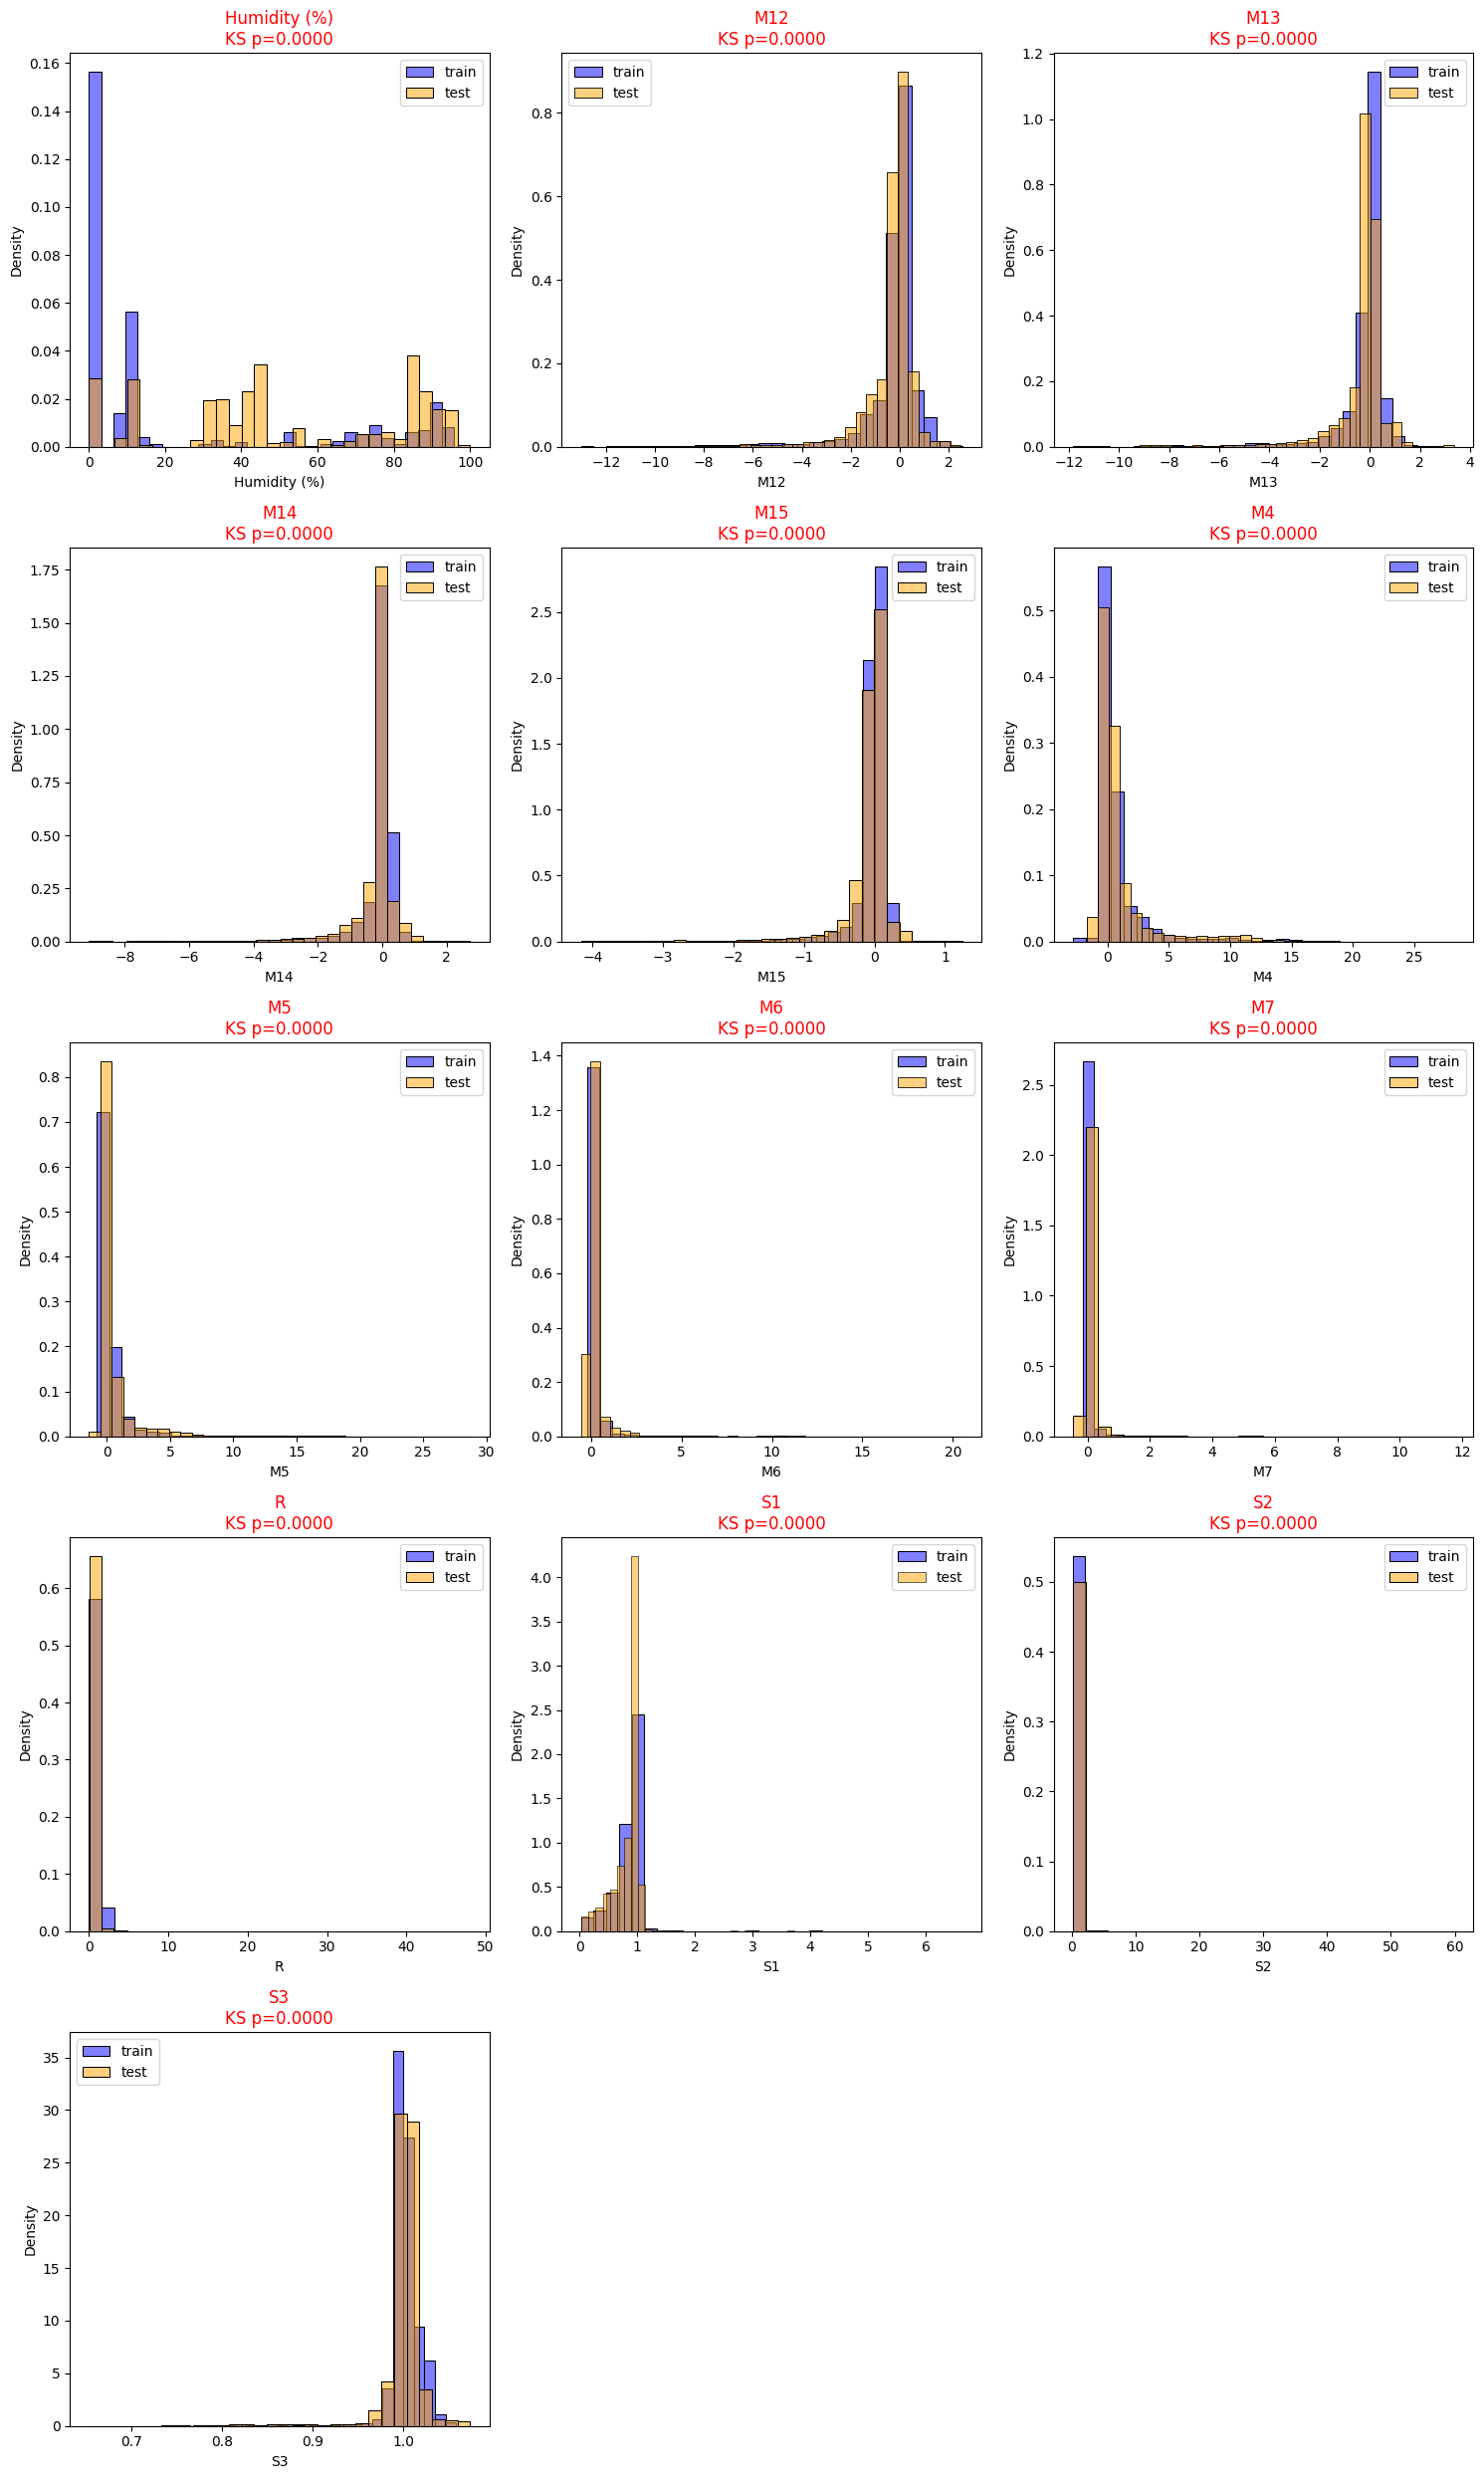


🚨 Features avec distribution différente (p < 0.05) :
  Humidity   → KS stat=0.5885, p=0.0000
  M12        → KS stat=0.1446, p=0.0000
  M13        → KS stat=0.1494, p=0.0000
  M14        → KS stat=0.1353, p=0.0000
  M15        → KS stat=0.1241, p=0.0000
  M4         → KS stat=0.1007, p=0.0000
  M5         → KS stat=0.1035, p=0.0000
  M6         → KS stat=0.0841, p=0.0000
  M7         → KS stat=0.0715, p=0.0000
  R          → KS stat=0.1817, p=0.0000
  S1         → KS stat=0.0619, p=0.0000
  S2         → KS stat=0.1332, p=0.0000
  S3         → KS stat=0.2301, p=0.0000


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\4009862785.py:84: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\4009862785.py:84: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\4009862785.py:84: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Utilisateur\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Utilisateur\AppData\Roaming\Python\Python

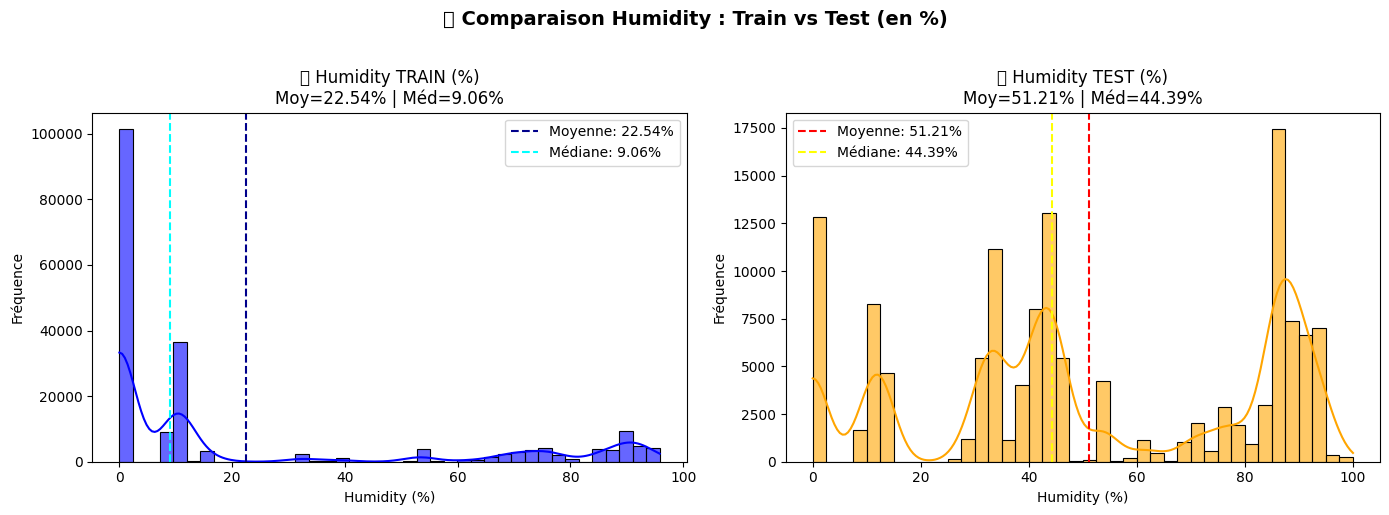


📊 Statistiques Humidity (en %) :
                       TRAIN       TEST
  Moyenne              22.54%      51.21%
  Médiane               9.06%      44.39%
  Écart-type           33.53%      31.15%
  Min                   0.03%       0.03%
  Max                  95.83%     100.00%

  🧪 KS test: stat=0.5885, p-value=0.0000 ⚠️ DIFFÉRENT


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def plot_train_test_distributions(X_train, X_test, vars_to_plot=None, n_cols=3, figsize=(15, 5)):
    if vars_to_plot is None:
        vars_to_plot = X_train.columns.tolist()

    n_vars = len(vars_to_plot)
    n_rows = (n_vars + n_cols - 1) // n_cols

    plt.figure(figsize=(figsize[0], n_rows * figsize[1]))

    for i, col in enumerate(vars_to_plot, 1):
        plt.subplot(n_rows, n_cols, i)

        train_data = X_train[col].dropna()
        test_data = X_test[col].dropna()

        # ✅ Convertir Humidity en pourcentage pour meilleure lisibilité
        if col == 'Humidity':
            train_data = train_data * 100
            test_data = test_data * 100

        sns.histplot(train_data, kde=False, color='blue', 
                     alpha=0.5, label='train', stat='density', bins=30)
        sns.histplot(test_data, kde=False, color='orange', 
                     alpha=0.5, label='test', stat='density', bins=30)

        # ✅ Test statistique KS pour mesurer le décalage
        stat, pval = ks_2samp(train_data, test_data)
        color = 'red' if pval < 0.05 else 'green'
        
        if col == 'Humidity':
            plt.title(f"{col} (%)\nKS p={pval:.4f}", color=color)
            plt.xlabel('Humidity (%)')
        else:
            plt.title(f"{col}\nKS p={pval:.4f}", color=color)
        plt.legend()

    plt.tight_layout()
    plt.show()

    # ✅ Résumé des features problématiques
    print("\n🚨 Features avec distribution différente (p < 0.05) :")
    for col in vars_to_plot:
        stat, pval = ks_2samp(X_train[col].dropna(), X_test[col].dropna())
        if pval < 0.05:
            print(f"  {col:10s} → KS stat={stat:.4f}, p={pval:.4f}")

plot_train_test_distributions(dfX, dftest, vars_to_plot=[
    'Humidity','M12','M13','M14','M15','M4','M5','M6','M7','R','S1','S2','S3'
])

# ============================================================
# ✅ ZOOM séparé sur Humidity (train vs test) en pourcentage
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Train ---
ax1 = axes[0]
humidity_train = dfX['Humidity'].dropna() * 100
sns.histplot(humidity_train, kde=True, color='blue', alpha=0.6, bins=40, ax=ax1)
ax1.set_title(f"🔵 Humidity TRAIN (%)\nMoy={humidity_train.mean():.2f}% | Méd={humidity_train.median():.2f}%", fontsize=12)
ax1.set_xlabel('Humidity (%)')
ax1.set_ylabel('Fréquence')
ax1.axvline(humidity_train.mean(), color='darkblue', linestyle='--', label=f'Moyenne: {humidity_train.mean():.2f}%')
ax1.axvline(humidity_train.median(), color='cyan', linestyle='--', label=f'Médiane: {humidity_train.median():.2f}%')
ax1.legend()

# --- Test ---
ax2 = axes[1]
humidity_test = dftest['Humidity'].dropna() * 100
sns.histplot(humidity_test, kde=True, color='orange', alpha=0.6, bins=40, ax=ax2)
ax2.set_title(f"🟠 Humidity TEST (%)\nMoy={humidity_test.mean():.2f}% | Méd={humidity_test.median():.2f}%", fontsize=12)
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Fréquence')
ax2.axvline(humidity_test.mean(), color='red', linestyle='--', label=f'Moyenne: {humidity_test.mean():.2f}%')
ax2.axvline(humidity_test.median(), color='yellow', linestyle='--', label=f'Médiane: {humidity_test.median():.2f}%')
ax2.legend()

plt.suptitle("📊 Comparaison Humidity : Train vs Test (en %)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ✅ Stats descriptives comparées
stat, pval = ks_2samp(humidity_train, humidity_test)
print("\n📊 Statistiques Humidity (en %) :")
print(f"  {'':15s} {'TRAIN':>10s} {'TEST':>10s}")
print(f"  {'Moyenne':15s} {humidity_train.mean():10.2f}% {humidity_test.mean():10.2f}%")
print(f"  {'Médiane':15s} {humidity_train.median():10.2f}% {humidity_test.median():10.2f}%")
print(f"  {'Écart-type':15s} {humidity_train.std():10.2f}% {humidity_test.std():10.2f}%")
print(f"  {'Min':15s} {humidity_train.min():10.2f}% {humidity_test.min():10.2f}%")
print(f"  {'Max':15s} {humidity_train.max():10.2f}% {humidity_test.max():10.2f}%")
print(f"\n  🧪 KS test: stat={stat:.4f}, p-value={pval:.4f} {'⚠️ DIFFÉRENT' if pval < 0.05 else '✅ SIMILAIRE'}")


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\2780817369.py:64: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\2780817369.py:64: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\2780817369.py:64: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_18424\2780817369.py:64: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Utilisateur\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Utilisateur\AppData\Roaming\Python\Python312\site-packages\IPython\core\py

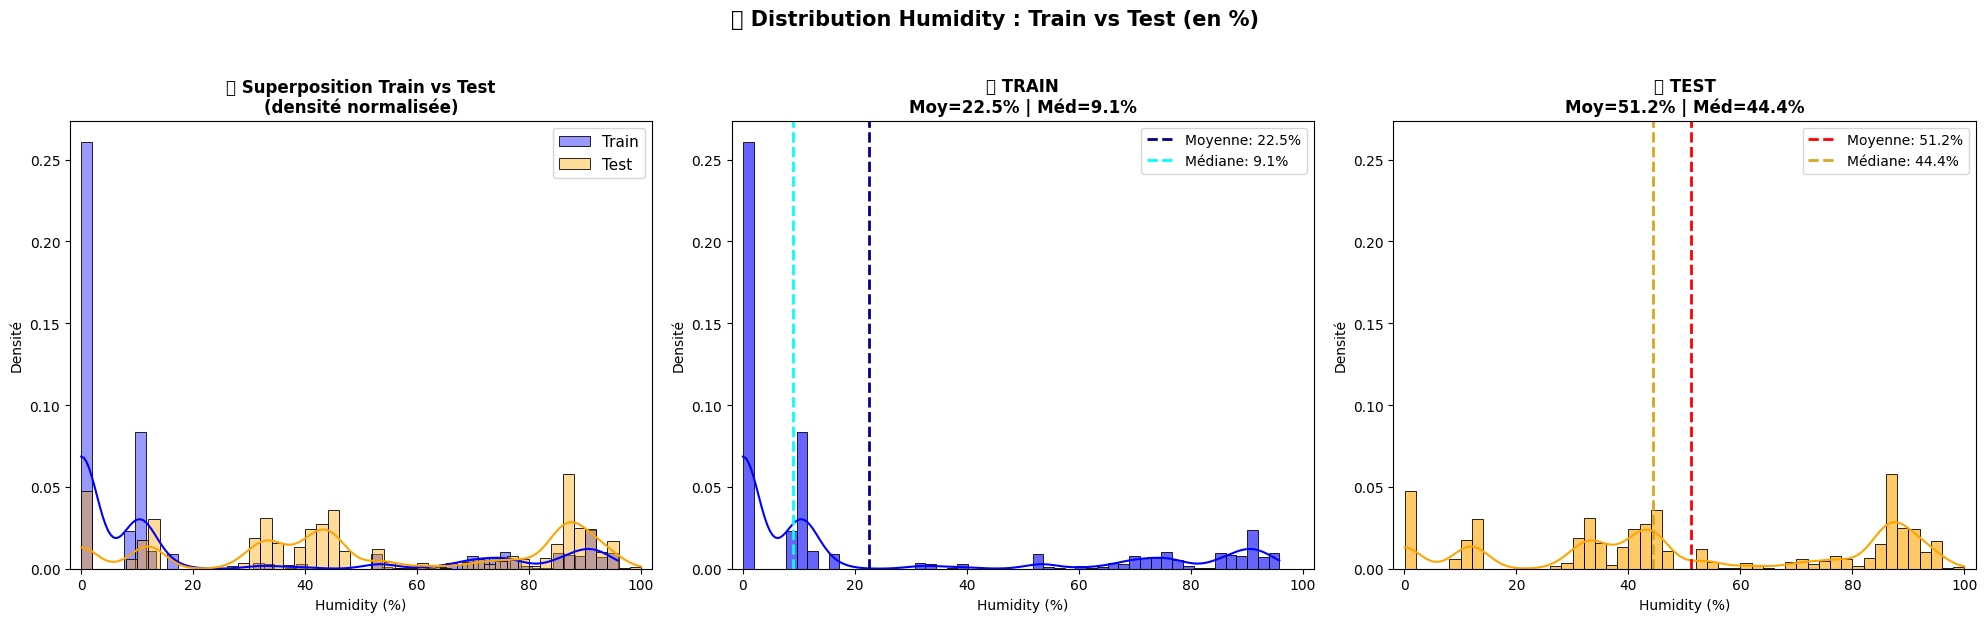


📊 RÉSUMÉ HUMIDITY (en %)
                          TRAIN       TEST       ÉCART
  --------------------------------------------------
  Moyenne                 22.5%      51.2%      +28.7%
  Médiane                  9.1%      44.4%      +35.3%
  Écart-type              33.5%      31.2%
  Min                      0.0%       0.0%
  Max                     95.8%     100.0%
  Q1 (25%)                 0.0%      32.0%
  Q3 (75%)                32.8%      86.2%

  🧪 Test KS: stat=0.5885, p-value=0.00e+00
  → ⚠️  DISTRIBUTIONS SIGNIFICATIVEMENT DIFFÉRENTES

  💡 Le test est +28.7% plus humide en moyenne que le train
     Train concentré autour de 9% (très sec)
     Test plus étalé autour de 44% (modérément humide)


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

humidity_train = dfX['Humidity'].dropna() * 100
humidity_test = dftest['Humidity'].dropna() * 100

# ============================================================
# 1. SUPERPOSITION sur le même graphique (même échelle)
# ============================================================
ax0 = axes[0]
sns.histplot(humidity_train, kde=True, color='blue', alpha=0.4, bins=50, 
             label='Train', stat='density', ax=ax0)
sns.histplot(humidity_test, kde=True, color='orange', alpha=0.4, bins=50, 
             label='Test', stat='density', ax=ax0)
ax0.set_title("🔀 Superposition Train vs Test\n(densité normalisée)", fontsize=12, fontweight='bold')
ax0.set_xlabel('Humidity (%)')
ax0.set_ylabel('Densité')
ax0.legend(fontsize=11)

# ============================================================
# 2. TRAIN seul
# ============================================================
ax1 = axes[1]
sns.histplot(humidity_train, kde=True, color='blue', alpha=0.6, bins=50, 
             stat='density', ax=ax1)
ax1.axvline(humidity_train.mean(), color='darkblue', linestyle='--', linewidth=2,
            label=f'Moyenne: {humidity_train.mean():.1f}%')
ax1.axvline(humidity_train.median(), color='cyan', linestyle='--', linewidth=2,
            label=f'Médiane: {humidity_train.median():.1f}%')
ax1.set_title(f"🔵 TRAIN\nMoy={humidity_train.mean():.1f}% | Méd={humidity_train.median():.1f}%", 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Humidity (%)')
ax1.set_ylabel('Densité')
ax1.legend(fontsize=10)

# ============================================================
# 3. TEST seul
# ============================================================
ax2 = axes[2]
sns.histplot(humidity_test, kde=True, color='orange', alpha=0.6, bins=50, 
             stat='density', ax=ax2)
ax2.axvline(humidity_test.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Moyenne: {humidity_test.mean():.1f}%')
ax2.axvline(humidity_test.median(), color='goldenrod', linestyle='--', linewidth=2,
            label=f'Médiane: {humidity_test.median():.1f}%')
ax2.set_title(f"🟠 TEST\nMoy={humidity_test.mean():.1f}% | Méd={humidity_test.median():.1f}%", 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Densité')
ax2.legend(fontsize=10)

# ✅ Même échelle X pour les 3 graphiques
xmin = min(humidity_train.min(), humidity_test.min()) - 2
xmax = max(humidity_train.max(), humidity_test.max()) + 2
for ax in axes:
    ax.set_xlim(xmin, xmax)

# ✅ Même échelle Y pour les graphiques individuels (train/test)
ymax_shared = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, ymax_shared)
ax2.set_ylim(0, ymax_shared)

plt.suptitle("📊 Distribution Humidity : Train vs Test (en %)", 
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ============================================================
# ✅ Résumé chiffré
# ============================================================
stat, pval = ks_2samp(humidity_train, humidity_test)

print("\n" + "="*60)
print("📊 RÉSUMÉ HUMIDITY (en %)")
print("="*60)
print(f"  {'':18s} {'TRAIN':>10s} {'TEST':>10s}  {'ÉCART':>10s}")
print(f"  {'-'*50}")
print(f"  {'Moyenne':18s} {humidity_train.mean():9.1f}% {humidity_test.mean():9.1f}%  {humidity_test.mean()-humidity_train.mean():+9.1f}%")
print(f"  {'Médiane':18s} {humidity_train.median():9.1f}% {humidity_test.median():9.1f}%  {humidity_test.median()-humidity_train.median():+9.1f}%")
print(f"  {'Écart-type':18s} {humidity_train.std():9.1f}% {humidity_test.std():9.1f}%")
print(f"  {'Min':18s} {humidity_train.min():9.1f}% {humidity_test.min():9.1f}%")
print(f"  {'Max':18s} {humidity_train.max():9.1f}% {humidity_test.max():9.1f}%")
print(f"  {'Q1 (25%)':18s} {humidity_train.quantile(0.25):9.1f}% {humidity_test.quantile(0.25):9.1f}%")
print(f"  {'Q3 (75%)':18s} {humidity_train.quantile(0.75):9.1f}% {humidity_test.quantile(0.75):9.1f}%")
print(f"\n  🧪 Test KS: stat={stat:.4f}, p-value={pval:.2e}")
print(f"  → {'⚠️  DISTRIBUTIONS SIGNIFICATIVEMENT DIFFÉRENTES' if pval < 0.05 else '✅ Distributions similaires'}")
print(f"\n  💡 Le test est {humidity_test.mean()-humidity_train.mean():+.1f}% plus humide en moyenne que le train")
print(f"     Train concentré autour de {humidity_train.median():.0f}% (très sec)")
print(f"     Test plus étalé autour de {humidity_test.median():.0f}% (modérément humide)")
print("="*60)


In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# ==============================
# 1. Charger les données
# ==============================
dfX = pd.read_csv('x_train.csv')
dftest = pd.read_csv('x_test.csv')

# Supprimer la colonne ID si elle existe
dfX = dfX.drop(columns=['ID'], errors='ignore')
dftest = dftest.drop(columns=['ID'], errors='ignore')

# ==============================
# 2. Créer les labels
# ==============================
# Train = 0, Test = 1
dfX['is_test'] = 0
dftest['is_test'] = 1

# ==============================
# 3. Concaténer verticalement
# ==============================
df_all = pd.concat([dfX, dftest], axis=0, ignore_index=True)

X = df_all.drop(columns=['is_test'])
y = df_all['is_test']

print(f"Train samples (label=0) : {(y==0).sum()}")
print(f"Test samples  (label=1) : {(y==1).sum()}")

# ==============================
# 4. Split pour évaluation
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 5. Donner plus de poids au Test
# ==============================
# Calculer les poids : Test (label=1) a 5x plus de poids
sample_weights = np.where(y_train == 1, 5.0, 1.0)

# ==============================
# 6. Entraîner le modèle
# ==============================
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# ==============================
# 7. Évaluation
# ==============================
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_val, y_pred, target_names=['Train', 'Test']))

# Recall du Test (ce qu'on veut ≥ 80%)
from sklearn.metrics import recall_score
recall_test = recall_score(y_val, y_pred, pos_label=1)
print(f"🎯 Recall Test (détection du Test) : {recall_test*100:.2f}%")
print(f"📊 AUC Score : {roc_auc_score(y_val, y_proba):.4f}")

# ==============================
# 8. Features les plus importantes
# ==============================
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP FEATURES (différences Train vs Test)")
print("="*50)
print(feature_imp.head(10))


Train samples (label=0) : 202933
Test samples  (label=1) : 134673

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Train       1.00      0.95      0.97     40587
        Test       0.93      1.00      0.96     26935

    accuracy                           0.97     67522
   macro avg       0.96      0.97      0.97     67522
weighted avg       0.97      0.97      0.97     67522

🎯 Recall Test (détection du Test) : 99.64%
📊 AUC Score : 0.9986

TOP FEATURES (différences Train vs Test)
     feature  importance
0   Humidity    0.497991
7         M6    0.126625
10        S1    0.069486
4        M15    0.057184
9          R    0.053090
6         M5    0.047689
11        S2    0.035314
12        S3    0.035076
2        M13    0.028640
8         M7    0.021333


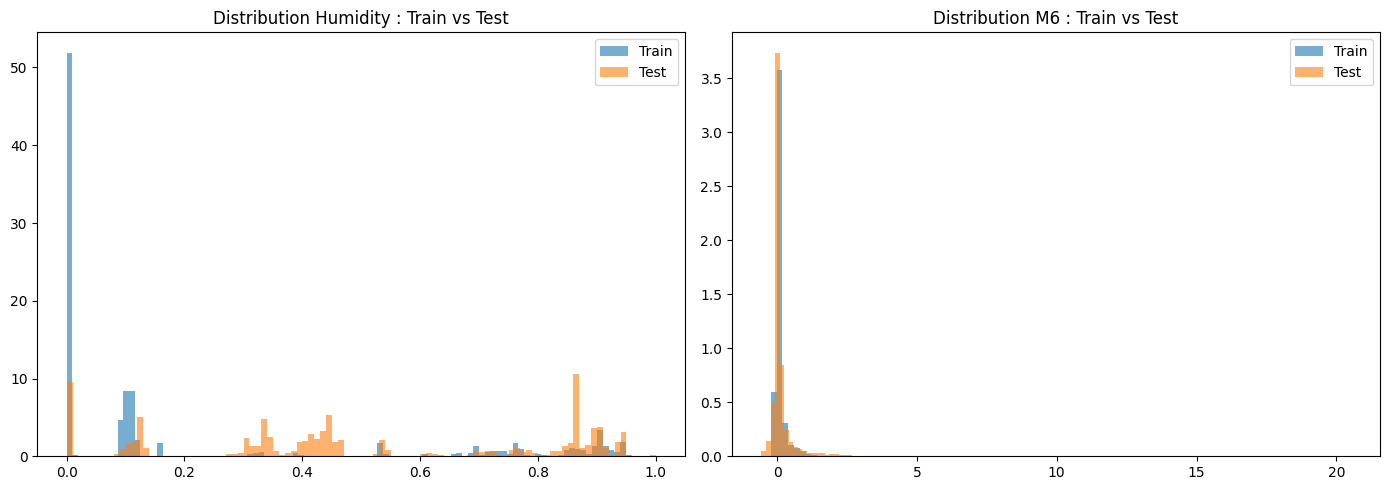

HUMIDITY :
  Train → mean=0.2254, std=0.3353
  Test  → mean=0.5121, std=0.3115

M6 :
  Train → mean=0.1753, std=0.8154
  Test  → mean=0.2162, std=0.9065


In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution Humidity
axes[0].hist(dfX['Humidity'], bins=100, alpha=0.6, label='Train', density=True)
axes[0].hist(dftest['Humidity'], bins=100, alpha=0.6, label='Test', density=True)
axes[0].set_title('Distribution Humidity : Train vs Test')
axes[0].legend()

# Distribution M6
axes[1].hist(dfX['M6'], bins=100, alpha=0.6, label='Train', density=True)
axes[1].hist(dftest['M6'], bins=100, alpha=0.6, label='Test', density=True)
axes[1].set_title('Distribution M6 : Train vs Test')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats comparatives
print("HUMIDITY :")
print(f"  Train → mean={dfX['Humidity'].mean():.4f}, std={dfX['Humidity'].std():.4f}")
print(f"  Test  → mean={dftest['Humidity'].mean():.4f}, std={dftest['Humidity'].std():.4f}")
print("\nM6 :")
print(f"  Train → mean={dfX['M6'].mean():.4f}, std={dfX['M6'].std():.4f}")
print(f"  Test  → mean={dftest['M6'].mean():.4f}, std={dftest['M6'].std():.4f}")
